# Multiple-scattering theory in one dimension


In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
#Parameters FIG.2
rA = 0.8
VA = -5
rB = 0.6
VB = -6
RAB = 2

xA = -1
xB = xA+RAB


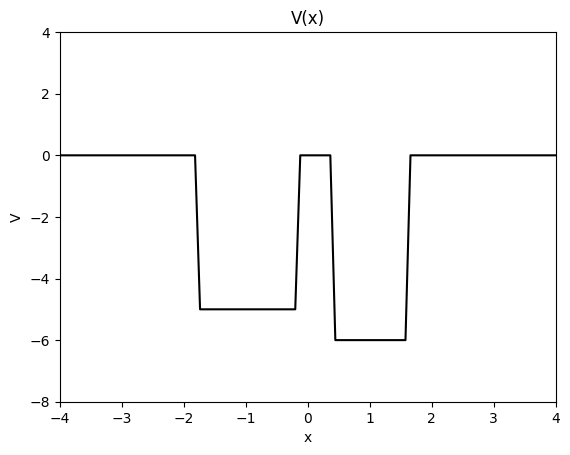

In [19]:
array_x = np.linspace(-4, 4, 100)

def potential(x):
    if (x>=xA-rA) and (x<=xA+rA):
        return VA
    elif (x>=xB-rB) and (x<=xB+rB):
        return VB
    else:
        return 0
    

V = np.array([potential(x) for x in array_x])
    
plt.plot(array_x, V, color = "black")
plt.title("V(x)")
plt.xlabel("x")
plt.ylabel("V")
plt.xlim(-4, 4)
plt.ylim(-8, 4)
plt.show()


Condition for the existence of solutions – secular equation

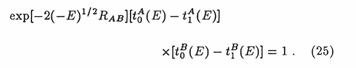

t matrix and $\gamma$

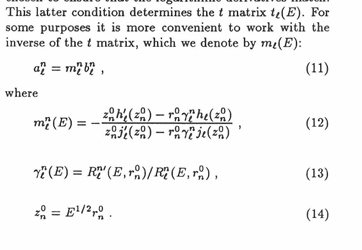

For single scatter


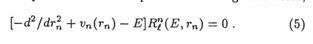

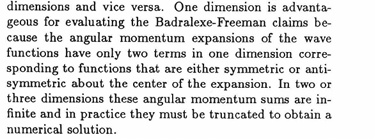

l = 0 -> symetric function


l = 1 -> anti-symetric function


**E>V**

$$
k=\sqrt{E-V}
$$


$$
k^2 = E-V
$$

$$
\frac{d^2R}{dx^2}=-k^2R
$$


$$
R(r)=C_1cos(kr)+C_2sin(kr)
$$

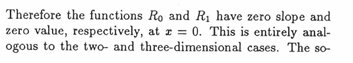

$$
R_0 = C_1cos(kr)
$$

$$
R_1 = C_2sin(kr)
$$

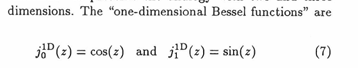

$$
\gamma_0=\frac{R'_0(r_0)}{R_0(r_0)}=\frac{-ksin(kr_0)}{cos(kr_0)}=-ktan(kr_0)
$$

$$
\gamma_1=\frac{k}{tan(kr_0)}
$$

**E<V**

$$
\kappa = \sqrt{V-E}
$$

$$
R(r)=C_1cosh(\kappa r)+C_2sinh(\kappa r)
$$

$$
\gamma_0=\kappa tanh(\kappa r_0)
$$

$$
\gamma_1=\frac{\kappa}{tanh(\kappa r_0)}
$$

In [20]:
def gamma(E, V, r):
    if(E>V):
        k = np.sqrt(E-V)
        gamma_0 = -k * np.tan(k*r)
        gamma_1 = k / np.tan(k*r)

    else:
        kappa = np.sqrt(V-E)
        gamma_0 = kappa * np.tanh(kappa*r)
        gamma_1 = kappa / np.tanh(kappa*r)

    return gamma_0, gamma_1


In [21]:
def m_matrix(E, gamma_0, gamma_1, r0):

    if(E >= 0):
        return np.nan, np.nan
    
    alpha = np.sqrt(-E)
    
    z = alpha * r0

    den0 = gamma_0 * np.cosh(z) - np.sqrt(-E) * np.sinh(z)
    den1 = gamma_1 * np.sinh(z) - np.sqrt(-E) * np.cosh(z)

    m0 = -np.exp(-z) * (alpha + gamma_0)/den0
    m1 = np.exp(-z) * (alpha + gamma_1)/den1

    return m0, m1

In [22]:
def secular(E, r_A, V_A, r_B, V_B, R_AB):

    alpha = np.sqrt(-E)

    gamma_0A, gamma_1A = gamma(E, V_A, r_A)
    gamma_0B, gamma_1B = gamma(E, V_B, r_B)

    m0A, m1A = m_matrix(E, gamma_0A, gamma_1A, r_A)
    m0B, m1B = m_matrix(E, gamma_0B, gamma_1B, r_B)

    term1 = np.exp(-2*alpha*R_AB) * (m1A-m0A) * (m1B-m0B)
    term2 = m0A*m1A*m0B*m1B

    result = term1-term2

    return result

In [23]:
from scipy.optimize import brentq
eigenenergies = []

#brentq -> searches for a root of the function within the interval
e1 = brentq(secular, -4.5, -3.5, args=(rA, VA, rB, VB, RAB))
e2 = brentq(secular, -3.5, -2.5, args=(rA, VA, rB, VB, RAB))


print("Calculated energies:")

print(f"E = {e1:.9f}")
print(f"E = {e2:.9f}")

print("\nEnergies FIG 2.:")
print("E = -3.949901757")
print("E = -3.22848704")

Calculated energies:
E = -3.949901756
E = -3.228487039

Energies FIG 2.:
E = -3.949901757
E = -3.22848704


In [24]:
def calc_psi_components(E):
    data = {}

    data['E'] = E

    alpha = np.sqrt(-E)

    data['alpha'] = alpha

    g0A, g1A = gamma(E, VA, rA)
    g0B, g1B = gamma(E, VB, rB)    
    m0A, m1A = m_matrix(E, g0A, g1A, rA)
    m0B, m1B = m_matrix(E, g0B, g1B, rB)   
    t0A = 1/m0A
    t1A = 1/m1A
    t0B = 1/m0B
    t1B = 1/m1B
    
    data['t0A'] = t0A
    data['t1A'] = t1A
    data['t0B'] = t0B
    data['t1B'] = t1B
    
    a0A = 1 #assumption
    a0B = np.exp(-alpha*RAB) * (t0A-t1A)*a0A #from (24b) and (11)
    
    data['a0A'] = a0A
    data['a0B'] = a0B

    #Region IA
    if(E>VA):
        k_A = np.sqrt(E-VA)
        R0A = np.cos(k_A*rA)
        R1A = np.sin(k_A*rA)

        data['k_A'] = k_A
    else:
        kappa_A = np.sqrt(VA-E)
        R0A = np.cosh(kappa_A*rA)
        R1A = np.sinh(kappa_A*rA)

        data['kappa_A'] = kappa_A
        
    #Region IB
    if(E>VB):
        k_B = np.sqrt(E-VB)
        R0B = np.cos(k_B*rB)
        R1B = np.sin(k_B*rB)

        data['k_B'] = k_B
    else:
        kappa_B = np.sqrt(VB-E)
        R0B = np.cosh(kappa_B*rB)
        R1B = np.sinh(kappa_B*rB)

        data['kappa_B'] = kappa_B

    c0A = a0A*np.cosh(alpha*rA) + a0A*t0A*np.exp(-alpha*rA) #from (3) and (27)
    c1A = a0A*np.sinh(alpha*rA) - a0A*t1A*np.exp(-alpha*rA)
    
    data['c0A'] = c0A/R0A
    data['c1A'] = c1A/R1A

    c0B = a0B*np.cosh(alpha*rB) + a0B*t0B*np.exp(-alpha*rB)
    c1B = -a0B*np.sinh(alpha*rB) + a0B*t1B* np.exp(-alpha*rB)

    data['c0B'] = c0B/R0B
    data['c1B'] = c1B/R1B
    
    return data

def calc_psi(x, data):

    E = data['E']
    alpha = data['alpha']
    rA_x = np.abs(x-xA)
    rB_x = np.abs(x-xB)

    #Region IA
    if rA_x <= rA:
        rA_hat = np.sign(x-xA)
        if E > VA:
            R0 = np.cos(data['k_A']*rA_x)
            R1 = np.sin(data['k_A']*rA_x)
        else:
            R0 = np.cosh(data['kappa_A']*rA_x)
            R1 = np.sinh(data['kappa_A']*rA_x)
        return data['c0A']*R0 + data['c1A']*R1* rA_hat
    
    #Region IB
    elif rB_x <= rB:
        rB_hat = np.sign(x-xB)
        if E > VB:
            R0 = np.cos(data['k_B']*rB_x)
            R1 = np.sin(data['k_B']*rB_x)
        else:
            R0 = np.cosh(data['kappa_B']*rB_x)
            R1 = np.sinh(data['kappa_B']*rB_x)
        return data['c0B']*R0 + data['c1B']*R1* rB_hat

    #Region II
    else:
        rA_hat = np.sign(x-xA)
        rB_hat = np.sign(x-xB)
        
        psi_A = data['a0A']*(data['t0A'] - data['t1A']*rA_hat) * np.exp(-alpha*rA_x)
        psi_B = data['a0B']*(data['t0B'] + data['t1B']*rB_hat) * np.exp(-alpha*rB_x)
        
        return psi_A + psi_B

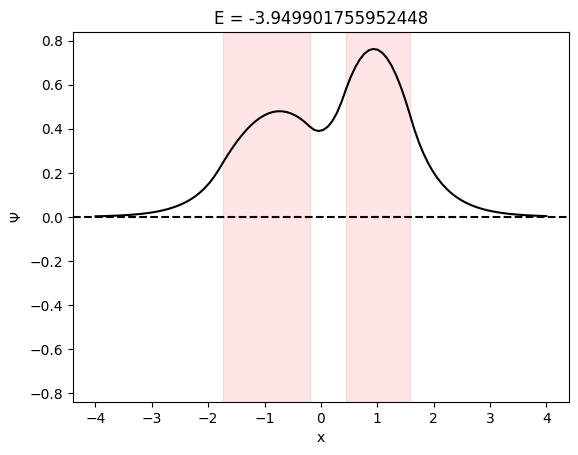

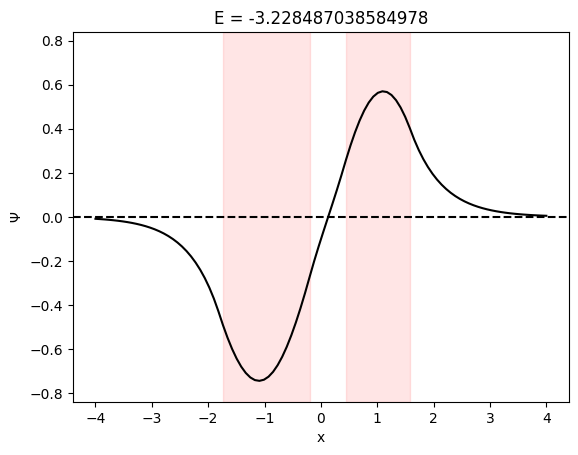

In [25]:
components_e1 = calc_psi_components(e1)
components_e2 = calc_psi_components(e2)

psi_e1 = np.array([calc_psi(x, components_e1) for x in array_x])
psi_e2 = np.array([calc_psi(x, components_e2) for x in array_x])

#rescaling graphs
# psi_e1 /= 100
# psi_e2 /= -100
# a = np.max(psi_e1)*1.1

# plt.plot(array_x, psi_e1, color='black')
# plt.axhline(0, ls='--', color='black')
# plt.fill_between(array_x, -a, a, where=V<0, color='red', alpha=0.1)
# plt.ylim(-a, a)
# plt.title(f"E = {e1}")
# plt.xlabel("x")
# plt.ylabel(f"$\Psi$")
# plt.show()


# plt.plot(array_x, psi_e2, color='black') 
# plt.axhline(0, ls='--',  color='black')
# plt.fill_between(array_x, -a, a, where=V<0, color='red', alpha=0.1)
# plt.ylim(-a, a)
# plt.title(f"E = {e2}")
# plt.xlabel("x")
# plt.ylabel(f"$\Psi$")
# plt.show()

import scipy.integrate 
integral_e1 = scipy.integrate.simpson((np.abs(psi_e1)**2), x = array_x)
integral_e2 = scipy.integrate.simpson((np.abs(psi_e2)**2), x = array_x)
norm_psi_e1 = psi_e1/np.sqrt(integral_e1)
norm_psi_e2 = psi_e2/np.sqrt(integral_e2)
a = np.max(norm_psi_e1)*1.1

plt.plot(array_x, norm_psi_e1, color='black')
plt.axhline(0, ls='--', color='black')
plt.fill_between(array_x, -a, a, where=V<0, color='red', alpha=0.1)
plt.ylim(-a, a)
plt.title(f"E = {e1}")
plt.xlabel("x")
plt.ylabel(f"$\Psi$")
plt.show()


plt.plot(array_x, norm_psi_e2, color='black') 
plt.axhline(0, ls='--',  color='black')
plt.fill_between(array_x, -a, a, where=V<0, color='red', alpha=0.1)
plt.ylim(-a, a)
plt.title(f"E = {e2}")
plt.xlabel("x")
plt.ylabel(f"$\Psi$")
plt.show()

- brentq - replace - we do not know ranges between which solution exists
- R_l - solve numerically, not analytically (OK for square wells though)
- object programming - scatterer as class (with potential, t/m, etc.)